# Identifying the age of the stars in the stream of galaxy 741

### Dimitra Giantsidi & Nolan Ottele 2026

#### This code uses basic data analysis functions from the online pynbody tutorials to identify the ages of the stars that form the stream of galaxy 741 (romulus zoom simulation).

In [1]:
# import all necessary libraries
import pynbody
import pylab
import numpy as np
import matplotlib.pyplot as plt

# import the snapshot and accessing the halo information
s = pynbody.load('../data/raw/romulus_zooms/r741.romulus25.3072g1HsbBH/r741.romulus25.3072g1HsbBH.004096/r741.romulus25.3072g1HsbBH.004096')
h = s.halos()

# identify the main halo
main_halo = h[1]

# initiate physical units
s.physical_units()

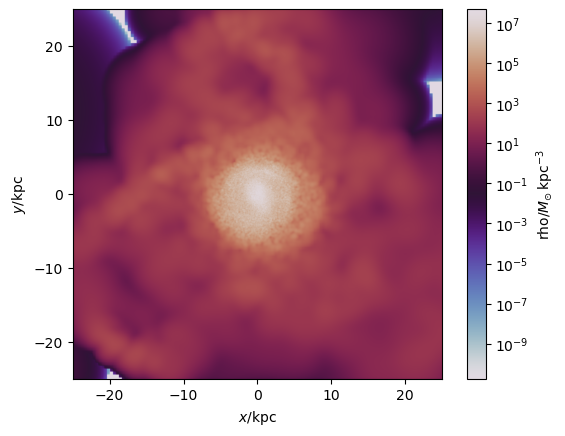

In [2]:
# density-weighted image of the stars of the galaxy face-on
pynbody.analysis.faceon(main_halo)
image_values = pynbody.plot.image(main_halo.star, width=50, cmap='twilight')

In [3]:
# filter out the center of the galaxy as it biased the color range
cen = main_halo.mean_by_mass('pos')
sphere_filter = ~pynbody.filt.Sphere('8 kpc', cen) # radius decided by eye
sphere_view = main_halo.star[sphere_filter]

Text(0.5, 1.0, 'Map of stars by density outside 8kpc from center of galaxy')

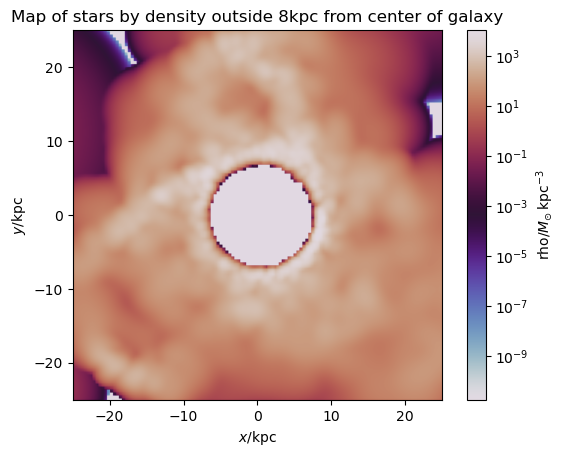

In [4]:
# density-weighted image of the stars of the galaxy excluding the center within an 8kpc radius
image_values = pynbody.plot.image(sphere_view, width=50, cmap='twilight')
pylab.title("Map of stars by density outside 8kpc from center of galaxy")

Text(0.5, 1.0, 'Map of stars by age outside 8kpc from center of galaxy')

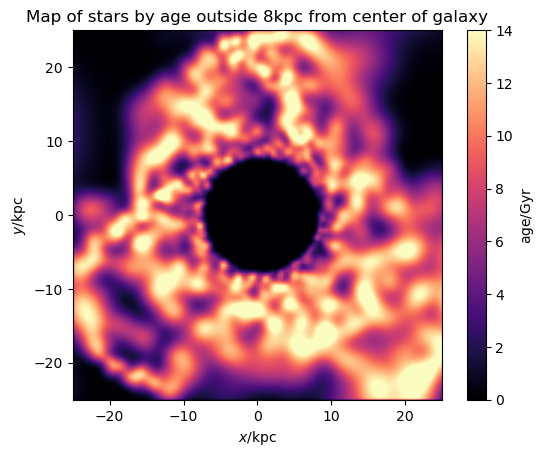

In [5]:
# age-weighted image of the stars of the main halo galaxy excluding the center within an 8kpc radius
image_values = pynbody.plot.image(sphere_view, qty='age', units="Gyr", log=False, width=50, cmap='magma', vmax=14)
pylab.title("Map of stars by age outside 8kpc from center of galaxy")

Text(0.5, 1.0, 'Star ages outside 8kpc from center of galaxy')

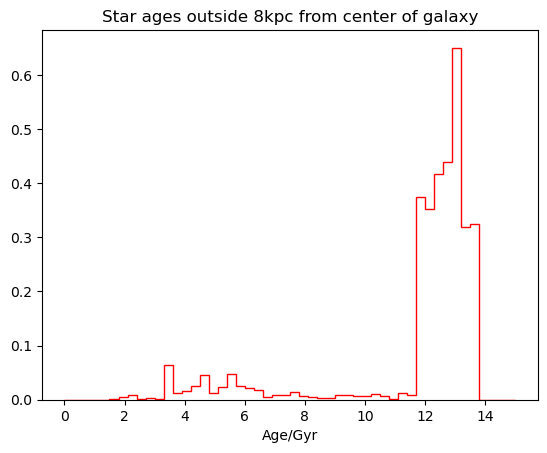

In [6]:
# histogram of the age of the stars of the main halo
pylab.hist(sphere_view['age'], bins=50, histtype='step', color='r', label='Stars', range=(0, 15), density=True)
pylab.xlabel("Age/Gyr")
pylab.ylabel("")
pylab.title("Star ages outside 8kpc from center of galaxy")

## Additional Analysis

In [7]:
# # access particle types of main halo
# print('ngas = %e, ndark = %e, nstar = %e\n'%(len(main_halo.gas),len(main_halo.dark),len(main_halo.star)))

# # assign the gas, dark matter and star profiles of the galaxy with parameters provided from the pynbody tutorial
# gas_profile = pynbody.analysis.Profile(main_halo.g, min=0.2, max=50,
#                                        type='log', nbins=50, ndim=3)

# dm_profile = pynbody.analysis.Profile(main_halo.d, min=0.2, max=50,
#                                       type='log', nbins=50, ndim=3)

# star_profile = pynbody.analysis.Profile(main_halo.s, min=0.2, max=50,
#                                         type='log', nbins=50, ndim=3)

# # density-weighted image of the galaxy center-oriented
# pynbody.analysis.center(main_halo)
# image_values = pynbody.plot.image(main_halo.d[pynbody.filt.Sphere('10 Mpc')], width=100, cmap='twilight')

# # density-weighted image of the gas of the galaxy center-oriented
# pynbody.analysis.center(main_halo)
# image_values = pynbody.plot.image(main_halo.gas, width=100, cmap='Blues')

# # density-weighted image of the dark matter of the galaxy
# pynbody.plot.image(s.d[pynbody.filt.Sphere('10 Mpc')],
#                    width='10 Mpc', units = 'Msol kpc^-2',
#                    cmap='Greys')

# # density-weighted image of the stars of the galaxy center-oriented
# pynbody.analysis.faceon(main_halo)
# image_values = pynbody.plot.image(main_halo.star, width=100, cmap='bone')

# # plotting the density of gas, dark matter and stars of the galaxy with respect to distance from the center
# pylab.plot(gas_profile['rbins'], gas_profile['density'], 'b', label='Gas')
# pylab.plot(dm_profile['rbins'], dm_profile['density'], 'k', label='Dark Matter')
# pylab.plot(star_profile['rbins'], star_profile['density'], 'r', label='Stars')
# pylab.loglog()
# pylab.xlabel('r [kpc]')
# pylab.ylabel(r'$\rho$ [M$_\odot$/kpc$^3$]')
# pylab.legend()

# # plotting the metallicity (Fe/H) of gas and stars of the galaxy
# pylab.hist(main_halo.g['feh'], bins=100, histtype='step', color='b', label='Gas', range=(-3.0, 0.2), density=True)
# pylab.hist(main_halo.s['feh'], bins=100, histtype='step', color='r', label='Stars', range=(-3.0, 0.2), density=True)
# pylab.xlabel("[Fe/H]")
# pylab.legend()

# # plotting the O/Fe vs. Fe/H metallicity of the stars of the galaxy
# pynbody.plot.hist2d(main_halo.s['feh'], main_halo.s['ofe'], logscale=True, cmap='Blues', nbins=128,
#                     x_range=(-3, 0.2), y_range=(-1, 1))
# pylab.xlabel("[Fe/H]")
# pylab.ylabel("[O/Fe]")

# rendering the stars of the main halo of the galaxy face-on
# with pynbody.analysis.faceon(main_halo):
#     pynbody.plot.stars.render(s, width="10 kpc", with_dust=True, mag_range=[18, 26])

# # plotting the stars of the main halo of the galaxy face-on zoomed out
# with pynbody.analysis.faceon(main_halo):
#     pynbody.plot.stars.render(s, width="30 kpc", with_dust=True, mag_range=[18, 30])

# # density-weighted image of the dark matter of the main halo zoomed out
# image_values = pynbody.plot.image(main_halo.dark, width=300, cmap='bone')

# # density-weighted image of the stars of the main halo zoomed out
# image_values = pynbody.plot.image(main_halo.star, width=40, cmap='copper')